##**[7주차]실습**


In [ ]:
print("학번, 이름")

학번, 이름


In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

2243372@donga.ac.kr


In [ ]:
# google drive 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 작업할 폴더 위치 설정 (본인 폴더 경로에 맞게 수정필요)
workspace = "/content/drive/MyDrive/2026_딥러닝/02 실습자료/7주차/실습/data"

In [ ]:
# 필요 라이브러리 import
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, models, layers
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from numpy import expand_dims
from matplotlib import pyplot
from matplotlib.image import imread
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

###**실습1) CIFAR-10 영상 분류하기**
- **[실습목표]** 예제를 통해 CNN 모델을 만들어 CIFAR-10 데이터에 대해 학습하고, 성능을 측정한다.



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


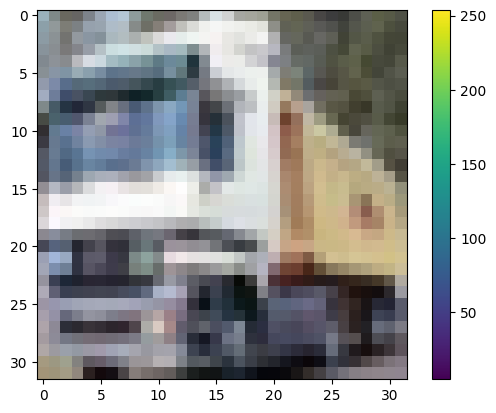

In [ ]:
# CFAR-10 데이터 세트를 적재한다.
# 훈련 세트와 테스트 세트를 반환받는다.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# 두 번째 영상(트럭)을 화면에 표시한다.
plt.figure()
plt.imshow(X_train[1])
plt.colorbar()

# 영상의 픽셀 값을 0에서 1 사이로 변환한다.(정규화)
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
# 순차 모델을 구축한다.
model = Sequential()
model.add(Conv2D(64, activation = 'relu', kernel_size = (3,3 )))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(32, activation = 'relu', kernel_size = (3,3 )))
model.add(Flatten(input_shape = (32, 32, 3)))
model.add(Dense(80, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

# 모델을 컴파일한다.
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 모델을 훈련한다.
history = model.fit(X_train, y_train, epochs=10, verbose=1,
                  validation_split=0.3)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4517 - loss: 1.5193 - val_accuracy: 0.5396 - val_loss: 1.2991
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5813 - loss: 1.1812 - val_accuracy: 0.6087 - val_loss: 1.1200
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6303 - loss: 1.0498 - val_accuracy: 0.6325 - val_loss: 1.0590
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6699 - loss: 0.9410 - val_accuracy: 0.6405 - val_loss: 1.0402
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6985 - loss: 0.8657 - val_accuracy: 0.6523 - val_loss: 1.0193
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7256 - loss: 0.7814 - val_accuracy: 0.6533 - val_loss: 1.0261
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7495 - loss: 0.7126 - val_accuracy: 0.6566 - val_loss: 1.0246
Epoch 8/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7748 - loss: 0.6408 -

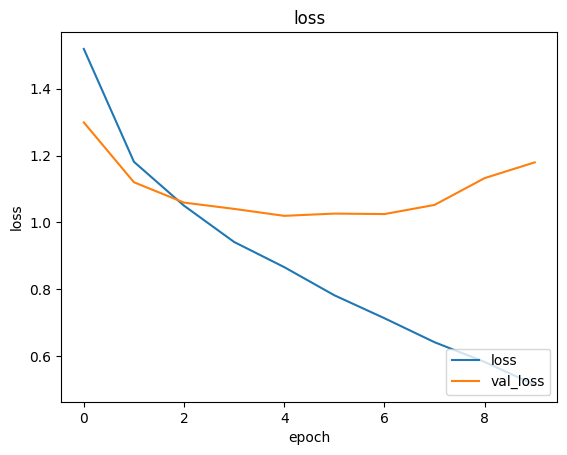

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
정답= [3]
예측값= [1.4963157e-04 3.3957171e-05 9.1974420e-04 9.3794358e-01 4.2379643e-03
 4.8971236e-02 7.5556119e-03 7.7630611e-06 1.6315756e-04 1.7324581e-05]


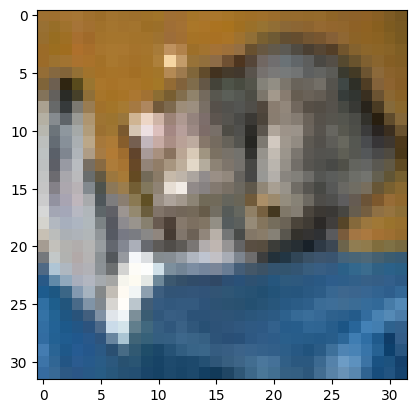

In [ ]:
# 손실값을 그래프로 그린다.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'], loc = 'lower right')
plt.show()

plt.figure()
plt.imshow(X_test[0])
y_pred = model.predict(X_test)
print("정답=", y_test[0])
print("예측값=", y_pred[0])
#훈련데이터/검증데이터 -> Overfitting

###**실습2) 데이터 증대**
- **[실습목표]** tensorflow의 함수를 사용하여 데이터 증대(Augmentation)를 적용하고, 증대가 적용된 데이터를 시각화 해본다.



In [ ]:
image = load_img(f"{workspace}/dog.jpg")
array = img_to_array(image)
sample = expand_dims(array, 0)

In [ ]:
datagen = ImageDataGenerator(rescale = 1./255, #픽셀값 0~1 변환
    rotation_range=90, brightness_range=[0.8, 1.0], #rotation +- 90도 회전 / 밝기 조절
    width_shift_range=0.2, zoom_range=[0.8, 1.2], # 좌우/위아래 이동, 확대/축소
    height_shift_range=0.2)

obj = datagen.flow(sample, batch_size=1)

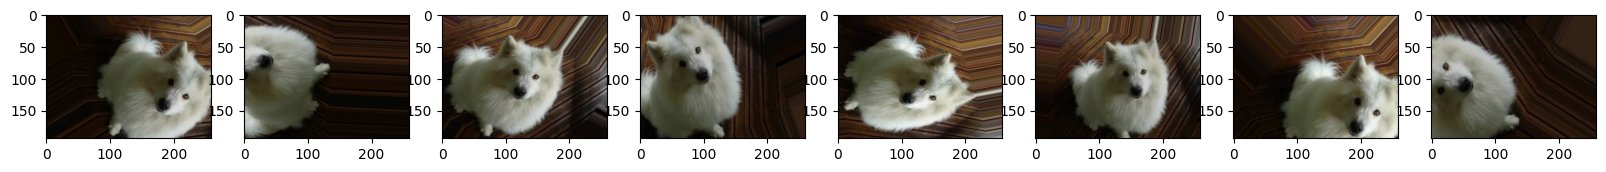

In [ ]:
fig = plt.figure(figsize=(20,5))

for i in range(8):
	plt.subplot(1,8,i+1)
	img = next(obj)
	plt.imshow(img[0])

###**실습3) 강아지와 고양이 구별하기**
- **[실습목표]** tensorflow의 함수를 사용하여 데이터 증대(Augmentation)를 적용하고, 증대가 적용된 데이터를 시각화 해본다.



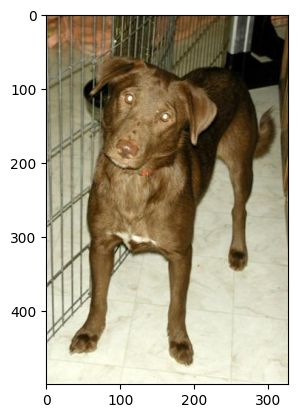

In [ ]:
import os
train_dir = os.path.join(workspace, 'PetImages', 'train')
test_dir = os.path.join(workspace, 'PetImages', 'test')

image = imread(os.path.join(train_dir, 'dog', '1.jpg'))
pyplot.imshow(image)
pyplot.show()


In [ ]:
#CNN 모델 구성
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dense(units=512, activation='relu'))
model.add(layers.Dense(units=1, activation='sigmoid'))

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


In [ ]:
#데이터 증강(학습 데이터만)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range = 0.2,  zoom_range = 0.2, horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

#폴더에서 데이터 자동 로딩(cat->0 / dog->1)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=20,
    class_mode = 'binary')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=20,
    class_mode = 'binary')

Found 2000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
history = model.fit(
    train_generator, steps_per_epoch = 100, epochs=10,
    validation_data=test_generator, validation_steps=5)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 435s 4s/step - accuracy: 0.5390 - loss: 0.8739 - val_accuracy: 0.6500 - val_loss: 0.6224
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 292ms/step - accuracy: 0.6295 - loss: 0.6545 - val_accuracy: 0.5900 - val_loss: 0.6830
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.6455 - loss: 0.6367 - val_accuracy: 0.6000 - val_loss: 0.7179
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.6820 - loss: 0.6079 - val_accuracy: 0.6400 - val_loss: 0.7466
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.7060 - loss: 0.5768 - val_accuracy: 0.6100 - val_loss: 0.7048
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 176ms/step - accuracy: 0.7200 - loss: 0.5577 - val_accuracy: 0.6700 - val_loss: 0.6862
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.7310 - loss: 0.5347 - val_accuracy: 0.6100 - val_loss: 0.7195
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.7565 - loss: 0.4

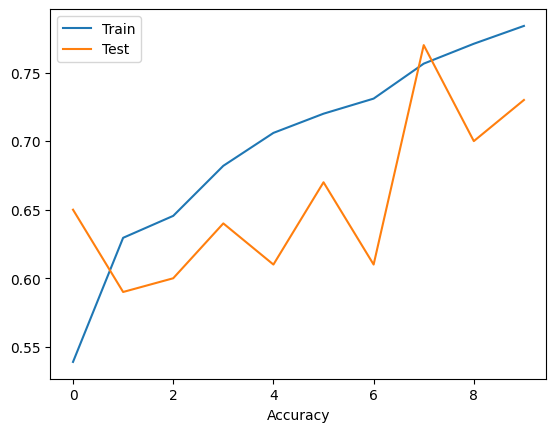

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.xlabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

###**실습4) 가중치 저장과 전이학습**


####**실습 4-1)**
  - 학습된 가중치의 저장 및 적재

In [ ]:
test_input = np.random.random((128, 32))
test_target = np.random.random((128, 1))

#모델 생성
inputs = tf.keras.Input(shape=(32,))
outputs = tf.keras.layers.Dense(1)(inputs)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(test_input, test_target, epochs=3)

#모델 저장(모델 전체 저장(구조/가중치/...))
model.save("my_model.keras")

Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0658  
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9426 
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8340 


In [ ]:
#모델 복원(이전 학습 상태 유지한 채 계속 학습-> loss 감소)
saved_model = tf.keras.models.load_model("my_model.keras")
saved_model.fit(test_input, test_target, epochs=3)

Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7316  
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6419 
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5606 


####**실습 4-2)**
  - ImageNet 데이터세트로 사전학습된 ResNet50을 다운로드 받아, 변경하지 않고 그대로 분류기로 사용해본다.

In [ ]:
#이미 학습된 모델로 이미지 분류
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
img_path = os.path.join(workspace, 'dog.jpg')
img = load_img(img_path, target_size=(224, 224)) #ResNet-224x224 입력만 받음
x = img_to_array(img) #이미지->숫자 배열 변환
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)	#ResNet이 학습할 때 사용한 방식으로 변환

In [ ]:
preds = model.predict(x)
print('예측:', decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
예측: [('n02111889', 'Samoyed', np.float32(0.95579463)), ('n02114548', 'white_wolf', np.float32(0.018570911)), ('n02112018', 'Pomeranian', np.float32(0.009478872))]


####**실습 4-3)**
  - 전이학습 예제 2
  - 사전 훈련된 모델을 특징 추출기 전처리기로 사용


In [ ]:
model = ResNet50(weights='imagenet')

img_path = os.path.join(workspace, 'dog.jpg')
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [ ]:
base_model=MobileNet(weights='imagenet',include_top=False) #학습된 모델/마지막 분류층 제거

x=base_model.output
x=GlobalAveragePooling2D()(x) #새로 학습
x=Dense(1024,activation='relu')(x)
x=Dense(1024,activation='relu')(x)
x=Dense(512,activation='relu')(x)
preds=Dense(2,activation='softmax')(x) #출력2개(강아지/고양이)

model=Model(inputs=base_model.input,outputs=preds)

/tmp/ipykernel_7232/2104566580.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNet(weights='imagenet',include_top=False) #imports the mobilenet model and discards the last 1000 neuron layer.


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#일부 layer만 학습
for layer in model.layers[:20]: #앞부분만
    layer.trainable=False
for layer in model.layers[20:]: #뒷부분만
    layer.trainable=True

In [ ]:
#데이터 로딩
train_datagen=ImageDataGenerator(preprocessing_function=preprocess_input) #(MobileNet 전처리)

train_generator=train_datagen.flow_from_directory(train_dir,
                                                 target_size=(128,128),
                                                 color_mode='rgb',
                                                 batch_size=32,
                                                 class_mode='categorical',
                                                 shuffle=True)

Found 2000 images belonging to 2 classes.


In [ ]:
#모델 학습
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

step_size_train=train_generator.n//train_generator.batch_size
model.fit(train_generator,
                   steps_per_epoch=step_size_train,
                   epochs=5)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 443ms/step - accuracy: 0.8044 - loss: 0.5106
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 207us/step - accuracy: 0.8438 - loss: 0.3755
Epoch 3/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9289 - loss: 0.2007
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 195us/step - accuracy: 0.8438 - loss: 0.3034
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9416 - loss: 0.1517
